# Monte Carlo Scatter Correction with SIMIND

This notebook demonstrates a **Monte Carlo-based scatter-correction workflow for Lu-177 SPECT** using **SIRF/STIR** and the **SIMIND Python connector**.

The workflow is:

1. Load measured photopeak projection data and the corresponding attenuation map.
2. Reconstruct an initial activity estimate with OSEM.
3. Use the reconstructed activity distribution and attenuation map as inputs to SIMIND.
4. Simulate the **scatter contribution in the photopeak window**.
5. Include the simulated scatter estimate as an **additive term** in the SPECT acquisition model.
6. Reconstruct the data again and compare the result with conventional energy-window scatter correction.

The purpose is to illustrate how Monte Carlo simulation can be incorporated into an iterative reconstruction workflow to obtain a physics-based estimate of scattered photons.

## Imports and paths

We first import SIRF/STIR, NumPy, the SIMIND connector, and the workshop utility functions.

The example below is configured for the **Lu-177 NEMA phantom** used elsewhere in the workshop. Adjust the measured-data paths if your projection data are stored under different filenames.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")

import sirf.STIR as spect
from simind_python_connector import StirSimindAdaptor
import stir_simind_utils as utils
spect.set_verbosity(0)

demo1_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1") 
demo2_path = Path("/home/jovyan/sirf-demo/SIRF-demo-2")

sim_dir = demo1_path / "simind_data" / "lu177_128"
input_dir = sim_dir / "input"
tomo_dir = sim_dir / "tomo"
mc_dir = demo2_path / "mc_scatter"
mc_dir.mkdir(parents=True, exist_ok=True)

## Load the measured projection data and attenuation map

For Monte Carlo scatter correction we require:

- the **measured photopeak projections** to be reconstructed;
- an **attenuation map** describing the object;
- the corresponding reconstruction geometry.

The attenuation map is used by both STIR and SIMIND. The orientation required by STIR may differ from the map passed to SIMIND, so a separate flipped copy is created for the STIR acquisition model.

In [30]:
# Change these paths if required for the measured dataset
measured_path = tomo_dir / "lu177_simulation_em_noisy.hs"
ctac_path = input_dir / "nema_lu_ctac.hv"

measured_data = spect.AcquisitionData(str(measured_path))
attenuation_map = spect.ImageData(str(ctac_path))

matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

initial_image = spect.ImageData(measured_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")
initial_image.fill(1)

# STIR attenuation-map orientation
attenuation_map_stir = attenuation_map.clone()
attenuation_map_stir.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)


INFO: Determined voxel size by dividing default_bin_size (4.42) by zoom


## Configure the SPECT acquisition model

The STIR system model describes the relationship between activity in image space and the measured projection data.

Here the model includes:

- **attenuation correction** using the attenuation map;
- **distance-dependent collimator-detector response modelling**.

Scatter is deliberately not included at this stage. The first reconstruction provides the activity estimate that will subsequently be used as the source distribution for the SIMIND Monte Carlo simulation.

In [ ]:
#sigma_0 = 2.35598  # mm
#slope = 0.01771

acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(False)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(
#    float(sigma_0),
#    float(slope),
#    full_3D=False
#)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)
acq_model.set_up(measured_data, initial_image)


INFO: Setting attenuation type to 'simple'

INFO: 2D PSF Correction. Parallel geometry

Parameters of SPECT UB matrix: (in cm)
Image grid side row: 128	col: 128	transverse voxel_size: 0.442
Number of slices: 128	slice_thickness: 0.442
Number of bins: 128	bin size: 0.442	axial size: 0.442
Number of angles: 120	angles (deg): {180, 177, 174, 171, 168, 165, 162, 159, 156, 153, 150, 147, 144, 141, 138, 135, 132, 129, 126, 123, 120, 117, 114, 111, 108, 105, 102, 99, 96, 93, 90, 87, 84, 81, 78, 75, 72, 69, 66, 63, 60, 57, 54, 51, 48, 45, 42, 39, 36, 33, 30, 27, 24, 21, 18, 15, 12, 9, 6.00001, 3, 0, -3, -6.00001, -9, -12, -15, -18, -21, -24, -27, -30, -33, -36, -39, -42, -45, -48, -51, -54, -57, -60, -63, -66, -69, -72, -75, -78, -81, -84, -87, -90, -93, -96, -99, -102, -105, -108, -111, -114, -117, -120, -123, -126, -129, -132, -135, -138, -141, -144, -147, -150, -153, -156, -159, -162, -165, -168, -171, -174, -177}

Number of subsets: 120
Correction for attenuation: 		do_msk_att: 0
Attenuat

## Initial OSEM reconstruction without scatter correction

An initial activity distribution is reconstructed from the photopeak data **without an explicit scatter estimate**.

This reconstruction is not intended to be the final quantitative image. Instead, it provides an estimate of the spatial activity distribution that SIMIND can use as its Monte Carlo source.

The PDF workflow similarly performs an initial OSEM reconstruction before passing the reconstructed image to SIMIND.

In [ ]:
subiterations = 100
subsets = 2

obj_fun = spect.make_Poisson_loglikelihood(measured_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

recon_image.write(str(mc_dir / "initial_reconstruction"))

## Prepare the activity estimate for SIMIND

Monte Carlo simulation is computationally expensive and is sensitive to noise in the source estimate. The initial reconstruction can therefore be smoothed before it is used as the SIMIND source distribution.

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Initial OSEM reconstruction'}>,
        <Axes: title={'center': 'Source used for SIMIND'}>], dtype=object))

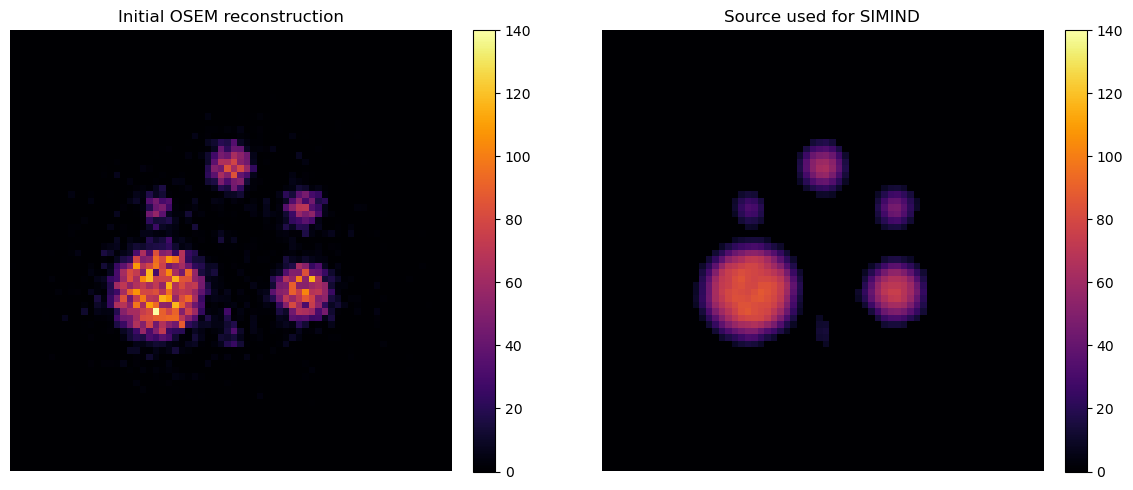

In [46]:
initial_reconstruction = spect.ImageData(str(mc_dir / "initial_reconstruction.hv"))

source_for_simind = initial_reconstruction.clone()

gaussian_filter = spect.SeparableGaussianImageFilter()
gaussian_filter.set_fwhms((9, 9, 9))
gaussian_filter.apply(source_for_simind)

source_arr = source_for_simind.as_array()
threshold = 0.1 * source_arr.max()
source_arr[source_arr < threshold] = 0
source_for_simind.fill(source_arr)

source_for_simind.write(str(mc_dir / "source_for_simind"))

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx])
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array()
    ],
    idx=idx,
    vmax=[vmax, vmax],
    titles=[
        "Initial OSEM reconstruction",
        "Source used for SIMIND"
    ]
)

## Configure the SIMIND Monte Carlo scatter simulation

SIMIND is now configured using the reconstructed activity estimate as the **source distribution** and the attenuation map as the object model.

For Lu-177, the principal imaging window is centred on the **208 keV emission**. The Monte Carlo simulation models photon transport through the phantom and detector system, including scattering events.

A low `photon_multiplier` is used during the workshop to reduce runtime. For quantitative work, substantially higher simulation statistics would normally be required.

In [47]:
# Lu-177 photopeak window
window_lower = [187.2]   # keV
window_upper = [228.8]   # keV
scatter_orders = [0]

config_file = demo1_path / "Discovery670_lu177.yaml"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(mc_dir),
    output_prefix="lu177_mc_scatter",
    photon_multiplier=0.05,
)

simind.set_source(source_for_simind)
simind.set_mu_map(attenuation_map)

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)

simind.add_runtime_switch("FI", "lu177")
simind.add_runtime_switch("CC", "ge-megp")
simind.add_runtime_switch("RR", 12345)

## Run SIMIND

SIMIND performs a Monte Carlo simulation of the estimated activity distribution.

The simulation produces separate projection datasets containing the **total**, **primary**, and/or **scattered** photon contributions, depending on the connector configuration. The scatter-only projection dataset is the quantity required for Monte Carlo scatter correction.

In [48]:
outputs = simind.run()

# Inspect the returned output mapping in case filenames differ
print(outputs)

INFO: Running SIMIND: simind lu177_mc_scatter lu177_mc_scatter /NN:0.05/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_mc_scatter  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_mc_scatter  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_mc_scatter_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_mc_scatter_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 40054          
 EnergyResolution...: 12           Spectra   Activity..........: 11110          
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 17.022         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_sca_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_tot_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/lu177_mc_scatter_tot_w1.hs


------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 62797.26819    
 NN ScalingFactor...: 0.05                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

## Load the Monte Carlo scatter estimate

The SIMIND **scatter-only projection data** are loaded as a SIRF/STIR `AcquisitionData` object.

The exact output filename depends on the connector version and configuration. The standard SIMIND connector output uses `_sca_w1.hs` for the scatter contribution in the first energy window.


Second Scatter Window present. Performing TEW...
Photopeak window width: 41.6
Scatter window 1 width: 27.2
Scatter window 2 width: 29.28


(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'SIMIND scatter estimate'}>,
        <Axes: title={'center': 'TEW scatter estimate'}>,
        <Axes: title={'center': 'Differnece Image'}>], dtype=object))

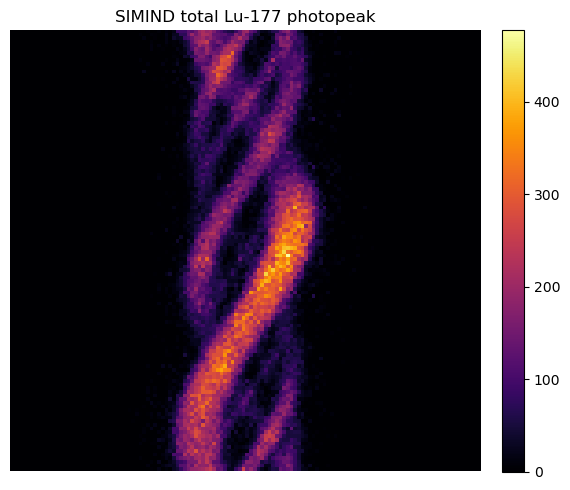

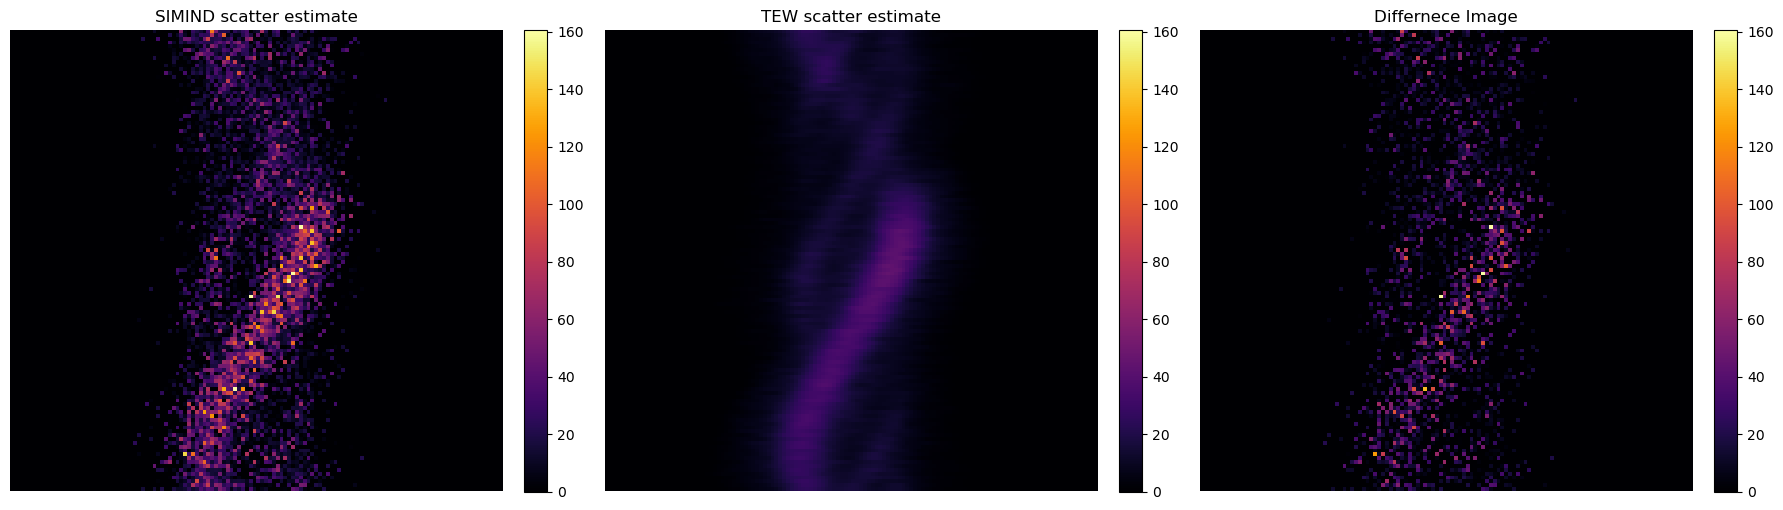

In [49]:
# simind estimates
total_path = mc_dir / "lu177_mc_scatter_tot_w1.hs"
scatter_path = mc_dir / "lu177_mc_scatter_sca_w1.hs"

# measured tew scatter
pp_path = demo1_path / "simind_data/lu177_128/output/lu177_simulation_tot_w1.hs"
sc1_path = demo1_path / "simind_data/lu177_128/output/lu177_simulation_tot_w2.hs"
sc2_path = demo1_path / "simind_data/lu177_128/output/lu177_simulation_tot_w3.hs"
acq_tew_cor, tew_scatter = utils.scatter_correction(
    PP_hdr=str(pp_path),
    SC1_hdr=str(sc1_path),
    SC2_hdr=str(sc2_path)
)

simind_total = spect.AcquisitionData(str(total_path))
simind_scatter = spect.AcquisitionData(str(scatter_path))

idx_proj = (56, slice(None), slice(None))

vmax = max(
    np.max(simind_scatter.as_array()[0][idx_proj]),
    np.max(tew_scatter.as_array()[0][idx_proj])
) / 2

utils.display_arr(
    arr_3d=measured_data.as_array()[0, :],
    idx=idx_proj,
    titles="SIMIND total Lu-177 photopeak"
)


utils.display_arr(
    arr_3d=[
        simind_scatter.as_array()[0, :],
        tew_scatter.as_array()[0, :],
        simind_scatter.as_array()[0, :] - tew_scatter.as_array()[0, :]
    ],
    idx=idx_proj,
    titles=[
        "SIMIND scatter estimate",
        "TEW scatter estimate",
        "Differnece Image"
    ],
    vmax=[vmax, vmax, vmax],
    vmin=[0, 0, 0],
    cmap=["inferno", "inferno", "inferno"]
)

In [ ]:
# Forward project the activity estimate using the STIR acquisition model
stir_projection = acq_model.forward(source_for_simind)

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'SIMIND total projection'}>,
        <Axes: title={'center': 'Measured projection'}>,
        <Axes: title={'center': 'STIR forward projection'}>], dtype=object))

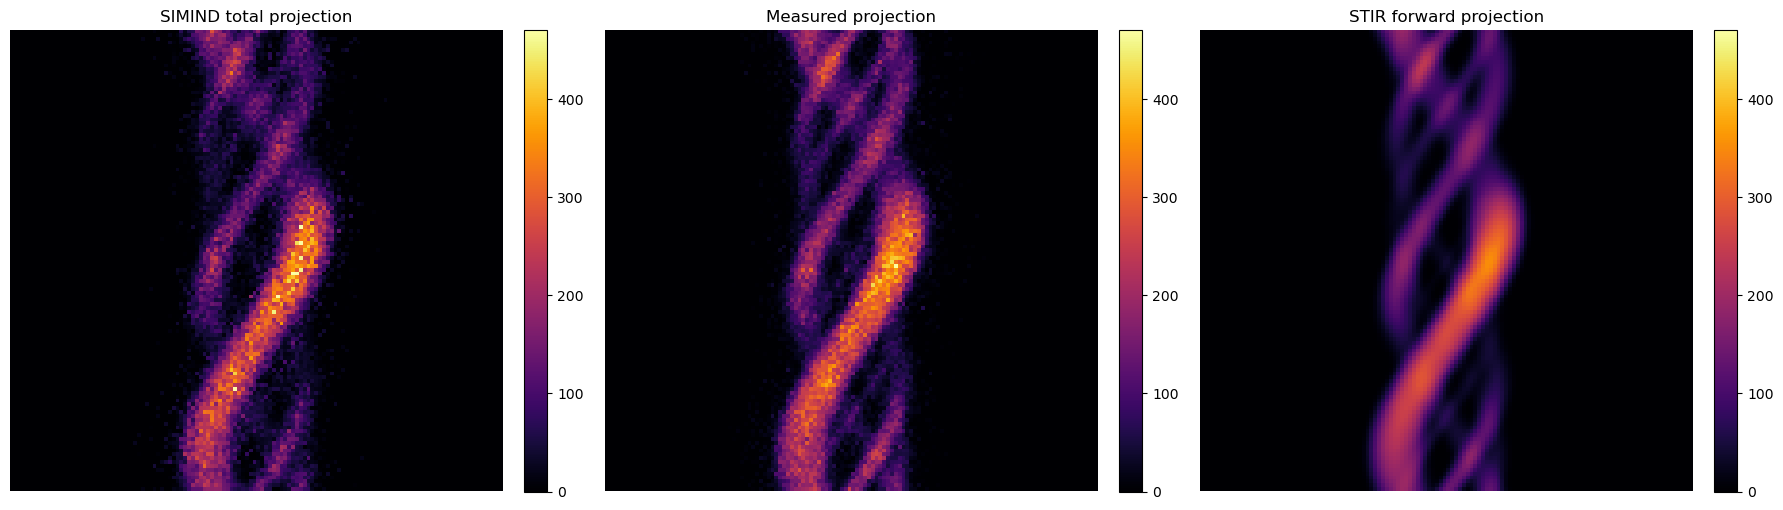

In [52]:
# Select a projection view
view = 56

simind_arr = simind_total.as_array()[0]
measured_arr = measured_data.as_array()[0]
stir_arr = stir_projection.as_array()[0]

utils.display_arr(
    arr_3d=[
        simind_arr,
        measured_arr,
        stir_arr
    ],
    idx=(view, slice(None), slice(None)),
    titles=[
        "SIMIND total projection",
        "Measured projection",
        "STIR forward projection"
    ],
    vmax=np.max(measured_arr[idx])
)

## Scale the Monte Carlo scatter estimate

The simulated scatter distribution must be on a scale consistent with the measured projection data before it can be used during reconstruction.

A practical implementation should determine the scaling from the simulation statistics, acquisition duration, activity calibration, or another explicitly defined normalisation procedure.

The cell below therefore keeps the scale factor explicit rather than hiding it inside the reconstruction.

In [26]:
scatter_scale = 1.0

scatter_estimate = simind_scatter * scatter_scale

## Reconstruction with Monte Carlo scatter correction

In the statistical SPECT model, scatter can be represented as an **additive contribution in projection space**:

\[
y = **A** x + s
\]

where:

- \(x\) is the activity image,
- \(A\) is the SPECT acquisition model,
- \(s\) is the estimated scatter projection,
- \(y\) is the expected measured projection data.

The SIMIND scatter estimate is therefore incorporated into the acquisition model as an **additive term**, rather than simply subtracting it from the measured projections.


In [ ]:
acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(True)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(
#    float(sigma_0),
#    float(slope),
#    full_3D=False
#)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)
scatter_estimate = spect.AcquisitionData(str(mc_dir / "lu177_mc_scatter_sca_w1.hs"))
acq_model.set_additive_term(scatter_estimate)
acq_model.set_up(measured_data, initial_image)

subiterations = 100
subsets = 2
save_interval = 10
name_prefix = "lu177_mc_recon"

obj_fun = spect.make_Poisson_loglikelihood(measured_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)

recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(mc_dir / name_prefix))
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

## Load the conventional TEW-corrected reconstruction

For comparison, we also use the reconstruction obtained with **triple-energy-window (TEW) scatter correction**.

This provides three reconstruction conditions:

1. **No scatter correction**
2. **SIMIND Monte Carlo scatter correction**
3. **TEW scatter correction**

In [55]:
mc_reconstruction = spect.ImageData(str(mc_dir / "lu177_mc_recon_100.hv"))

tew_recon_path = (
    demo1_path / "simind_data/lu177_128/recons/osem/lu177_sim_osem_100.hv"
)

# Replace the path above with the reconstruction generated from the
# TEW-corrected projection data if stored separately.
tew_reconstruction = spect.ImageData(str(tew_recon_path))

## Compare the reconstructed images

The three reconstruction strategies are displayed using the same image region and intensity scale.

This comparison illustrates the effect of the scatter estimate on reconstructed contrast and background activity. A visual comparison is useful, but quantitative assessment should also be performed using known phantom regions, for example recovery coefficients or activity-concentration bias.

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'OSEM - no scatter correction'}>,
        <Axes: title={'center': 'OSEM - SIMIND scatter correction'}>,
        <Axes: title={'center': 'OSEM - TEW scatter correction'}>],
       dtype=object))

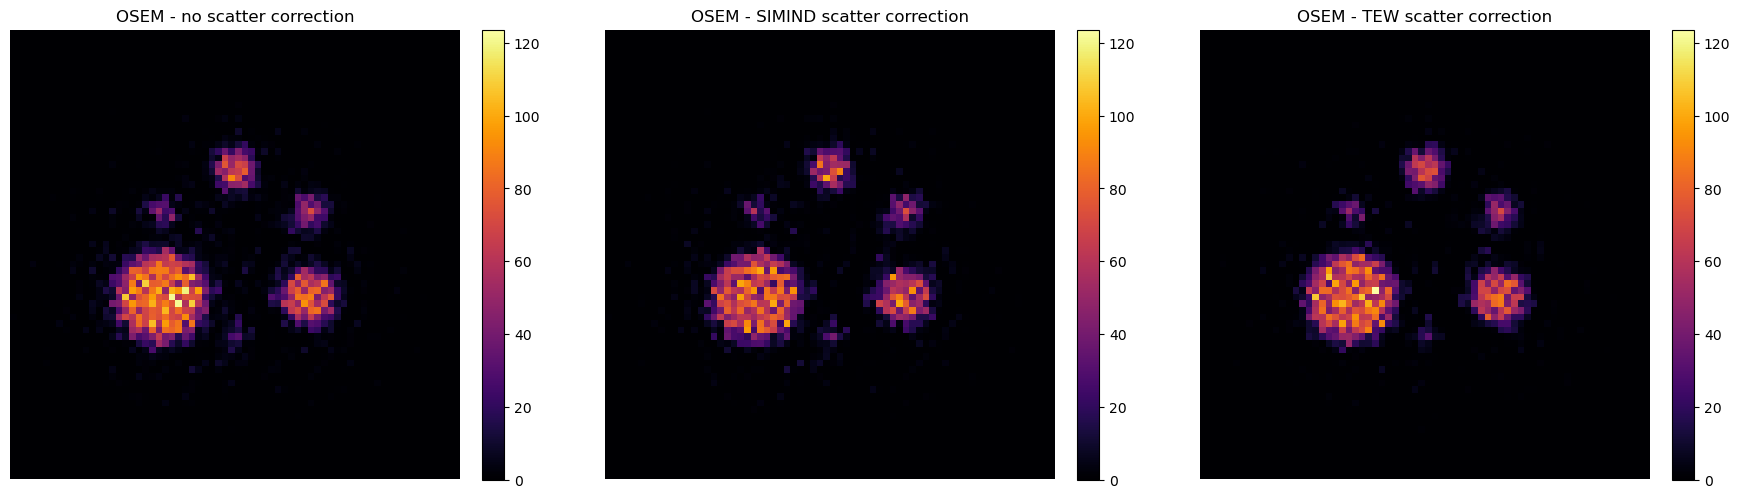

In [56]:
idx = (56, slice(30, 98), slice(30, 98))

recon_arrays = [
    initial_reconstruction.as_array(),
    mc_reconstruction.as_array(),
    tew_reconstruction.as_array(),
]

vmax = max(np.max(arr[idx]) for arr in recon_arrays)

utils.display_arr(
    arr_3d=recon_arrays,
    idx=idx,
    vmax=[vmax] * 3,
    titles=[
        "OSEM - no scatter correction",
        "OSEM - SIMIND scatter correction",
        "OSEM - TEW scatter correction"
    ]
)

## Summary

This notebook demonstrates a **reconstruction-driven Monte Carlo scatter-correction workflow**:

**measured projections → initial reconstruction → SIMIND scatter simulation → additive scatter model → final reconstruction**

Unlike DEW/TEW methods, which estimate scatter from neighbouring energy windows, the Monte Carlo approach estimates scatter by explicitly modelling photon transport through the reconstructed source and attenuation distribution.

### Points to consider

- The quality of the Monte Carlo scatter estimate depends on the accuracy of the **initial activity estimate** and **attenuation map**.
- The simulated scatter projections must be **correctly normalised** to the measured acquisition.
- Monte Carlo noise should be sufficiently low that it does not introduce additional structure into the reconstruction.
- Camera, collimator, energy-resolution, acquisition-geometry, and radionuclide settings should match the measured acquisition.
- Monte Carlo scatter correction is substantially more computationally demanding than energy-window methods, but provides a more explicit physical model of scatter.

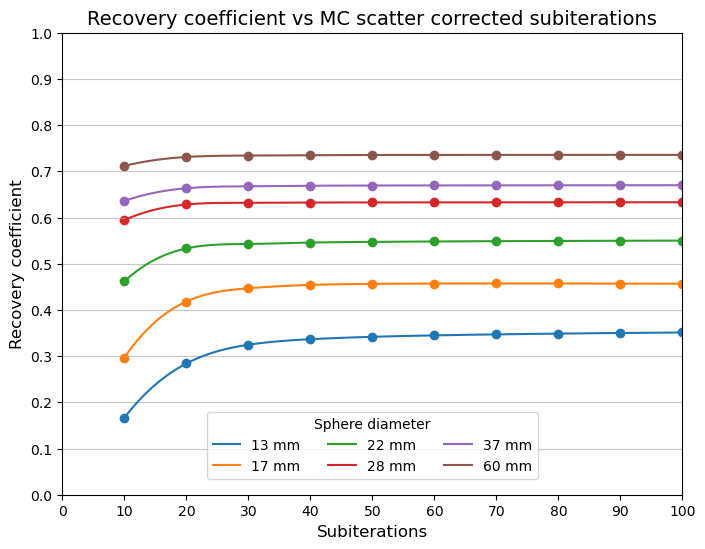

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Ground Truth'}>,
        <Axes: title={'center': 'MC scatter reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

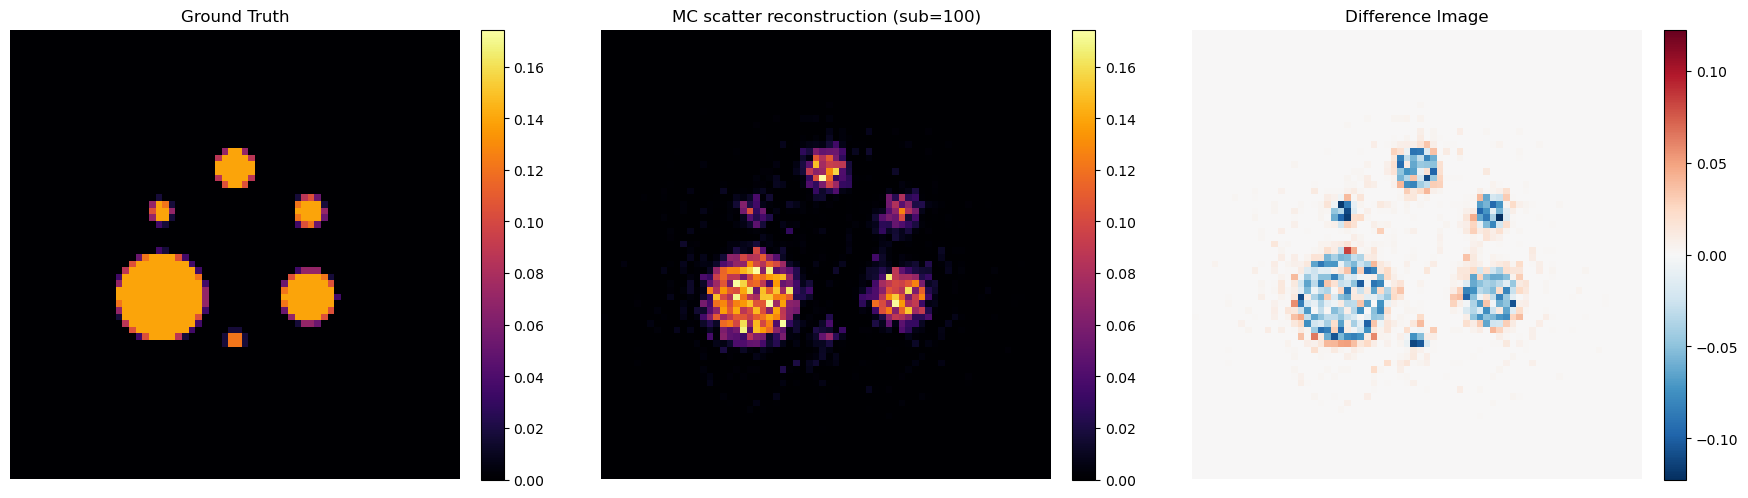

In [58]:
recon_prefix = "lu177_mc_recon"

input_dir = demo1_path / "simind_data" / "lu177_128" / "input"
recon_dir = mc_dir

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / "nema_lu_act.hv")
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / "masks_lu.npz")
)

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=False
)
diametre_mm = [13, 17, 22, 28, 37, 60]
utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs MC scatter corrected subiterations"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"Ground Truth", 
        f"MC scatter reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)